# 01. ROSE and LROM for a Single Scattering Wavefunction

This notebook is the first end-to-end demonstration of the stateful
`lrom.LROM` API. It compares high-fidelity solutions of the nuclear
scattering equation with ROSE/RBM and LROM approximations for the
exact $l=0$ channel of $^{40}$Ca(n,n) at 14.1 MeV.

All horizontal axes use physical radius $r$ in fm. The package owns
LROM numerical state; the ROSE comparison is constructed here in the
notebook with the public `nuclear-rose` package, sharing the exact
`phi0` and basis vectors the package built, so Galerkin and learned
coefficients live in the same reduced space.

## Notebook inputs

Two independent objects make the scientific distinction explicit:

- `vv_emulator`: `ws_1`, a Vv-only linspace study with normalized parameter predictors.
- `ws3_emulator`: `ws_3`, a Vv/Rv/av Latin-hypercube study with six selected potential predictors.

Both use a four-vector wavefunction basis and an eight-vector EIM basis.
Training and testing domains are deliberately separate so interpolation
and extrapolation behavior can be examined.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "lrom").is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for name in list(sys.modules):
    if name == "lrom" or name.startswith("lrom."):
        del sys.modules[name]

import scipy.special
if not hasattr(scipy.special, "sph_harm") and hasattr(scipy.special, "sph_harm_y"):
    # legacy sph_harm took (theta=azimuthal, phi=polar); sph_harm_y takes (polar, azimuthal)
    scipy.special.sph_harm = lambda m, n, theta, phi: scipy.special.sph_harm_y(n, m, phi, theta)

import rose
import lrom

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

## Section 1. Parameter Varying Vv

The first object isolates the effect of the real Woods-Saxon depth.
Its testing interval is wider than its training interval.

In [2]:
vv_emulator = lrom.LROM(
    target=(40, 20),
    projectile=(1, 0),
    lab_energy=14.1,
    l=0,
    fom="nucl-scatter-eq",
    potential="ws_1",
)
vv_center = dict(vv_emulator.central_parameters)
Vv0 = vv_center["Vv"]
vv_training_ranges = {"Vv": (0.90 * Vv0, 1.10 * Vv0)}
vv_testing_ranges = {"Vv": (0.65 * Vv0, 1.35 * Vv0)}

vv_emulator.sampling(
    training_ranges=vv_training_ranges,
    testing_ranges=vv_testing_ranges,
    training_size=35,
    testing_size=41,
    mesh_size=800,
    strategy="linspace",
    seed=1204,
    eim_basis_size=8,
)
vv_emulator.train(
    basis_size=4,
    predictor="parameters",
    predictor_count=1,
)

print("central parameters:", dict(vv_emulator.central_parameters))
print("training wavefunctions:", vv_emulator.samples.training_wavefunctions[0].shape)
print("testing wavefunctions:", vv_emulator.samples.testing_wavefunctions[0].shape)

# Notebook-owned ROSE emulator on the package's exact reduced basis:
# hand ROSE the same phi0 and basis vectors, then let it do Galerkin.
vv_rose_basis = rose.basis.CustomBasis(
    solutions=np.asarray(vv_emulator.samples.training_wavefunctions[0], dtype=np.complex128).T.copy(),
    phi_0=np.asarray(vv_emulator.samples.central_wavefunctions[0], dtype=np.complex128).copy(),
    rho_mesh=vv_emulator.samples.mesh.rho,
    n_basis=4,
    solver=vv_emulator.full_order_model[0].solver,
    subtract_phi0=True,
    use_svd=True,
    center=False,
    scale=False,
)
vv_rose_basis.vectors = np.asarray(vv_emulator.basis[0].vectors, dtype=np.complex128)
vv_rose_basis.phi_0 = np.asarray(vv_emulator.basis[0].phi0, dtype=np.complex128)
vv_rose_rbe = rose.reduced_basis_emulator.ReducedBasisEmulator(
    vv_emulator.full_order_model[0].interaction,
    vv_rose_basis,
    s_0=vv_emulator.full_order_model[0].base_solver.s_0,
    initialize_emulator=True,
)
vv_test_rows = vv_emulator.samples.design.testing.values
vv_rose_coefficients = np.asarray([vv_rose_rbe.coefficients(row) for row in vv_test_rows])
vv_rose_wavefunctions = np.asarray([vv_rose_rbe.emulate_wave_function(row) for row in vv_test_rows])
vv_fom_test = vv_emulator.samples.testing_wavefunctions[0]

central parameters: {'Vv': 48.822175142383706, 'Rv': 4.053875273743491, 'av': 0.671852}
training wavefunctions: (35, 800)
testing wavefunctions: (41, 800)


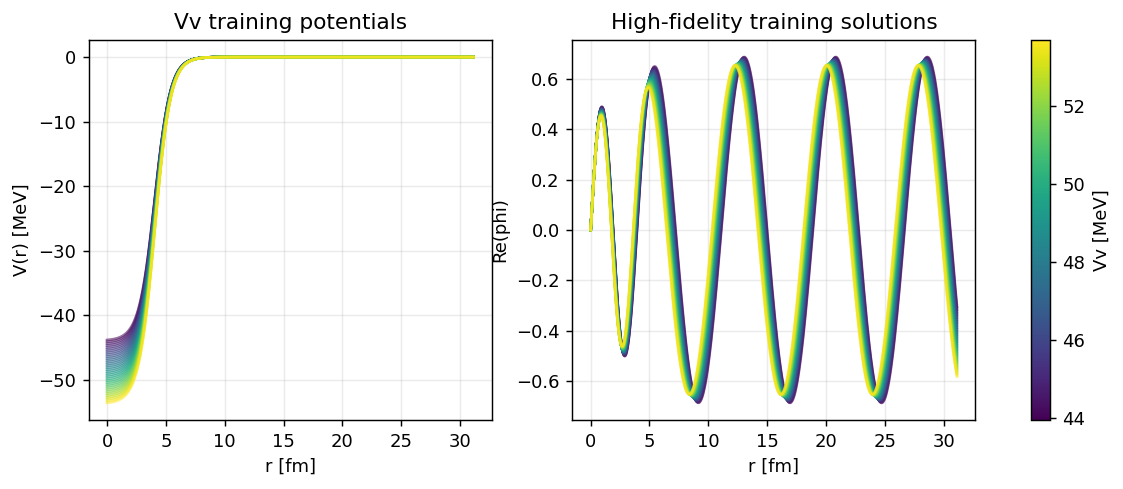

In [3]:
r = vv_emulator.mesh.radius
vv_values = vv_emulator.samples.design.training.values[:, 0]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
colors = plt.cm.viridis(np.linspace(0, 1, len(vv_values)))
for color, value, potential, phi in zip(
    colors,
    vv_values,
    vv_emulator.samples.training_potentials,
    vv_emulator.samples.training_wavefunctions[0],
):
    axes[0].plot(r, np.real(potential), color=color, alpha=0.55)
    axes[1].plot(r, np.real(phi), color=color, alpha=0.55)
axes[0].set(xlabel="r [fm]", ylabel="V(r) [MeV]", title="Vv training potentials")
axes[1].set(xlabel="r [fm]", ylabel="Re(phi)", title="High-fidelity training solutions")
fig.colorbar(
    plt.cm.ScalarMappable(
        norm=plt.Normalize(vv_values.min(), vv_values.max()), cmap="viridis"
    ),
    ax=axes,
    label="Vv [MeV]",
)
plt.show()

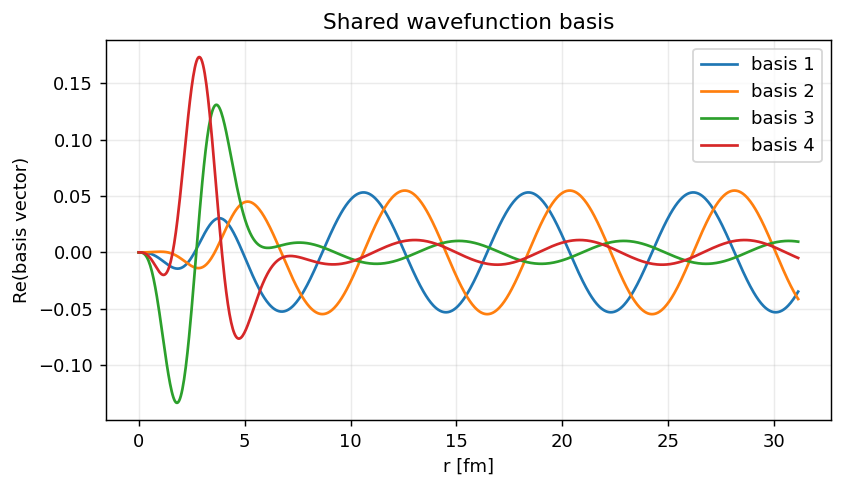

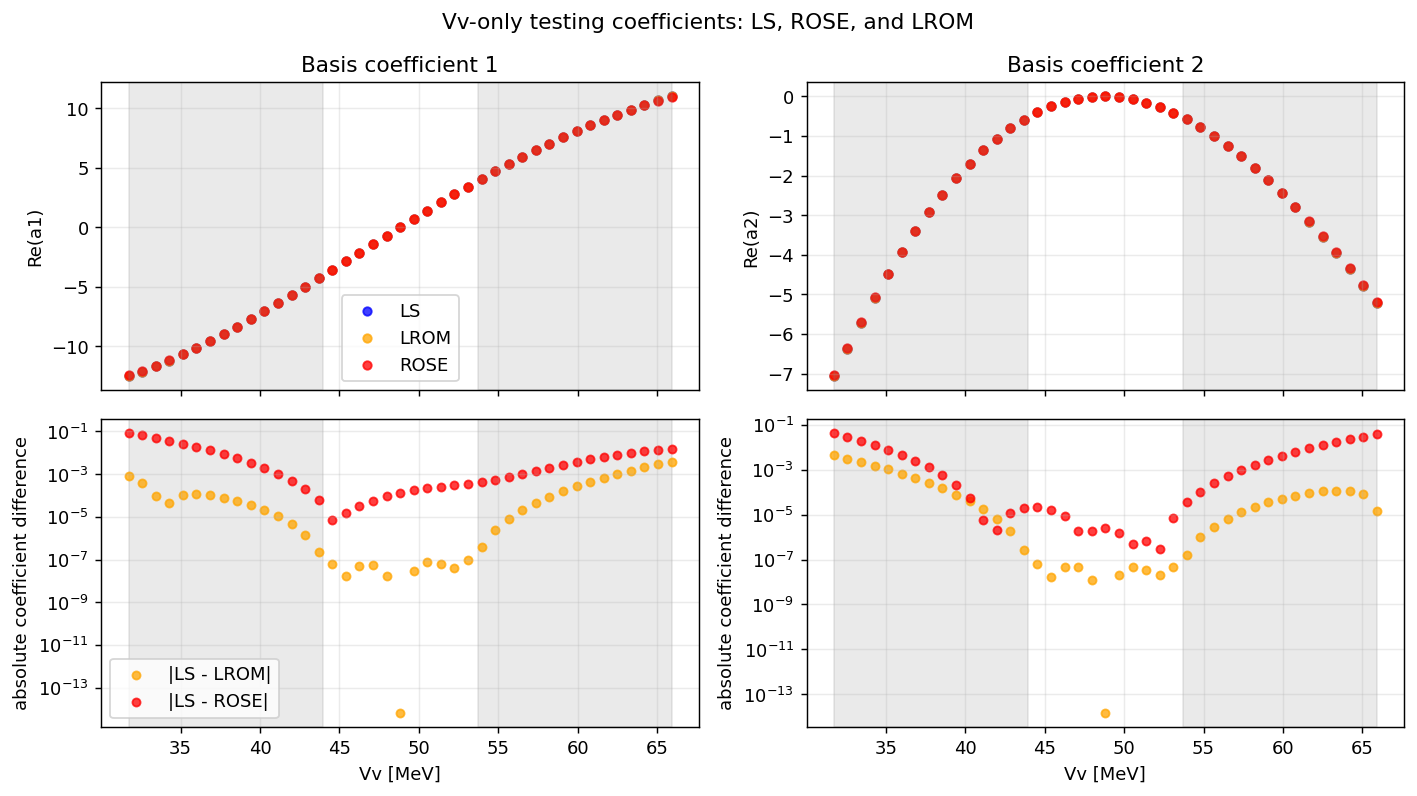

In [4]:
basis = vv_emulator.basis[0]
fig, ax = plt.subplots(figsize=(7.2, 3.8))
for index in range(basis.basis_size):
    ax.plot(r, np.real(basis.vectors[:, index]), label=f"basis {index + 1}")
ax.set(xlabel="r [fm]", ylabel="Re(basis vector)", title="Shared wavefunction basis")
ax.legend()
plt.show()

vv_test = vv_emulator.samples.design.testing.values[:, 0]
coefficients = {key: dict(value) for key, value in vv_emulator.testing_results.coefficients.items()}
coefficients["rose"] = {0: vv_rose_coefficients}
vv_train_low, vv_train_high = vv_training_ranges["Vv"]
fig, axes = plt.subplots(2, 2, figsize=(11.0, 6.2), sharex="col")
for coefficient_index in range(2):
    ax = axes[0, coefficient_index]
    difference_ax = axes[1, coefficient_index]
    for method, color in (("ls", "blue"), ("lrom", "orange"), ("rose", "red")):
        ax.scatter(
            vv_test,
            np.real(coefficients[method][0][:, coefficient_index]),
            s=22,
            color=color,
            alpha=0.75,
            label=method.upper(),
        )
    ax.axvspan(vv_test.min(), vv_train_low, color="gray", alpha=0.16)
    ax.axvspan(vv_train_high, vv_test.max(), color="gray", alpha=0.16)
    difference_ax.axvspan(vv_test.min(), vv_train_low, color="gray", alpha=0.16)
    difference_ax.axvspan(vv_train_high, vv_test.max(), color="gray", alpha=0.16)
    ls_coefficients = np.real(coefficients["ls"][0][:, coefficient_index])
    for method, color in (("lrom", "orange"), ("rose", "red")):
        method_coefficients = np.real(coefficients[method][0][:, coefficient_index])
        difference_ax.scatter(
            vv_test,
            np.maximum(np.abs(ls_coefficients - method_coefficients), 1e-16),
            s=20,
            color=color,
            alpha=0.75,
            label=f"|LS - {method.upper()}|",
        )
    ax.set_ylabel(f"Re(a{coefficient_index + 1})")
    ax.set_title(f"Basis coefficient {coefficient_index + 1}")
    difference_ax.set_yscale("log")
    difference_ax.set_xlabel("Vv [MeV]")
    difference_ax.set_ylabel("absolute coefficient difference")
axes[0, 0].legend()
axes[1, 0].legend()
fig.suptitle("Vv-only testing coefficients: LS, ROSE, and LROM")
fig.tight_layout()
plt.show()

selected Vv testing case: test-0020 {'Vv': 48.82217514238371, 'Rv': 4.053875273743491, 'av': 0.671852}


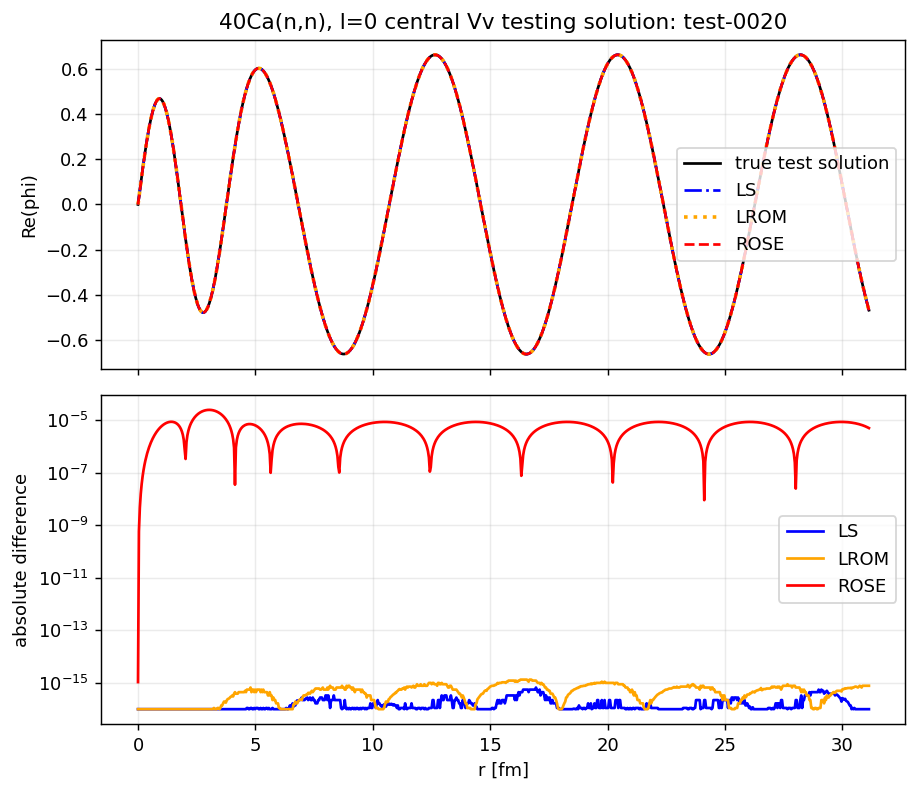

In [5]:
vv_representative_index = len(vv_test) // 2
vv_representative_id = vv_emulator.samples.design.testing.case_ids[vv_representative_index]
vv_case = vv_emulator.testing_case(case_id=vv_representative_id)
print("selected Vv testing case:", vv_representative_id, dict(vv_case.parameters))

fig, axes = plt.subplots(2, 1, figsize=(7.2, 6.2), sharex=True)
axes[0].plot(vv_case.radius, np.real(vv_case.high_fidelity[0]), color="black", label="true test solution")
axes[0].plot(vv_case.radius, np.real(vv_case.ls[0]), "-.", color="blue", label="LS")
axes[0].plot(vv_case.radius, np.real(vv_case.lrom[0]), ":", color="orange", linewidth=2, label="LROM")
axes[0].plot(vv_case.radius, np.real(vv_rose_wavefunctions[vv_representative_index]), "--", color="red", label="ROSE")
axes[0].set_ylabel("Re(phi)")
axes[0].set_title(f"40Ca(n,n), l=0 central Vv testing solution: {vv_representative_id}")
axes[0].legend()
axes[1].plot(vv_case.radius, np.maximum(np.abs(vv_case.high_fidelity[0] - vv_case.ls[0]), 1e-16), color="blue", label="LS")
axes[1].plot(vv_case.radius, np.maximum(np.abs(vv_case.high_fidelity[0] - vv_case.lrom[0]), 1e-16), color="orange", label="LROM")
axes[1].plot(vv_case.radius, np.maximum(np.abs(vv_case.high_fidelity[0] - vv_rose_wavefunctions[vv_representative_index]), 1e-16), color="red", label="ROSE")
axes[1].set_yscale("log")
axes[1].set_xlabel("r [fm]")
axes[1].set_ylabel("absolute difference")
axes[1].legend()
fig.tight_layout()
plt.show()

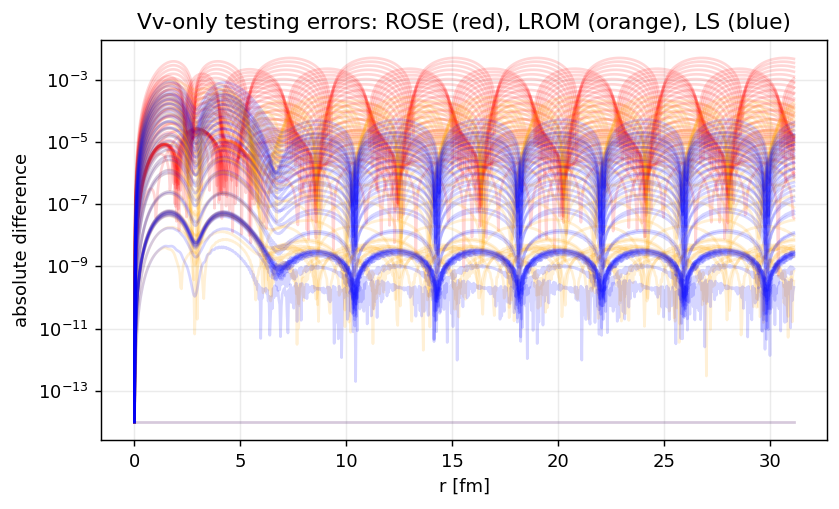

In [6]:
vv_errors = dict(vv_emulator.testing_errors[0])
vv_errors["rose"] = np.abs(vv_rose_wavefunctions - vv_fom_test)
fig, ax = plt.subplots(figsize=(7.2, 4.0))
for method, color in (("rose", "red"), ("lrom", "orange"), ("ls", "blue")):
    for error in vv_errors[method]:
        ax.plot(r, np.maximum(error, 1e-14), color=color, alpha=0.16)
ax.set_yscale("log")
ax.set_xlabel("r [fm]")
ax.set_ylabel("absolute difference")
ax.set_title("Vv-only testing errors: ROSE (red), LROM (orange), LS (blue)")
plt.show()

## Section 2. Three-Parameter LROM Equation And Predictor Selection

The second object varies Vv, Rv, and av together. Its default potential
predictors are values of the Woods-Saxon potential at six physical radii
selected from the training ensemble by SVD and maxvol-style selection.

The transformed equation has the form
$(I + p_1M_1 + \cdots + p_KM_K)a = \sum_k p_kb_k$.
The constant source $b_0$ is identically zero here because the
predictors and the reduced coordinates are both centered on the
reference solution: $p = 0$ must give $a = 0$.

In [7]:
ws3_emulator = lrom.LROM(
    target=(40, 20),
    projectile=(1, 0),
    lab_energy=14.1,
    l=0,
    fom="nucl-scatter-eq",
    potential="ws_3",
)
ws3_center = dict(ws3_emulator.central_parameters)
ws3_training_ranges = {
    name: (0.90 * ws3_center[name], 1.10 * ws3_center[name])
    for name in ("Vv", "Rv", "av")
}
ws3_testing_ranges = {
    "Vv": (0.78 * ws3_center["Vv"], 1.22 * ws3_center["Vv"]),
    "Rv": (0.80 * ws3_center["Rv"], 1.20 * ws3_center["Rv"]),
    "av": (0.80 * ws3_center["av"], 1.20 * ws3_center["av"]),
}

ws3_emulator.sampling(
    training_ranges=ws3_training_ranges,
    testing_ranges=ws3_testing_ranges,
    training_size=70,
    testing_size=81,
    mesh_size=900,
    strategy="latin_hypercube",
    seed=1204,
    eim_basis_size=8,
)
ws3_emulator.train(
    basis_size=4,
    predictor="potential",
    predictor_count=6,
)

# Same notebook-owned ROSE construction as Section 1, on the ws_3 basis.
ws3_rose_basis = rose.basis.CustomBasis(
    solutions=np.asarray(ws3_emulator.samples.training_wavefunctions[0], dtype=np.complex128).T.copy(),
    phi_0=np.asarray(ws3_emulator.samples.central_wavefunctions[0], dtype=np.complex128).copy(),
    rho_mesh=ws3_emulator.samples.mesh.rho,
    n_basis=4,
    solver=ws3_emulator.full_order_model[0].solver,
    subtract_phi0=True,
    use_svd=True,
    center=False,
    scale=False,
)
ws3_rose_basis.vectors = np.asarray(ws3_emulator.basis[0].vectors, dtype=np.complex128)
ws3_rose_basis.phi_0 = np.asarray(ws3_emulator.basis[0].phi0, dtype=np.complex128)
ws3_rose_rbe = rose.reduced_basis_emulator.ReducedBasisEmulator(
    ws3_emulator.full_order_model[0].interaction,
    ws3_rose_basis,
    s_0=ws3_emulator.full_order_model[0].base_solver.s_0,
    initialize_emulator=True,
)
ws3_train_rows = ws3_emulator.samples.design.training.values
ws3_test_rows = ws3_emulator.samples.design.testing.values
ws3_rose_coefficients = np.asarray([ws3_rose_rbe.coefficients(row) for row in ws3_test_rows])
ws3_rose_wf_train = np.asarray([ws3_rose_rbe.emulate_wave_function(row) for row in ws3_train_rows])
ws3_rose_wf_test = np.asarray([ws3_rose_rbe.emulate_wave_function(row) for row in ws3_test_rows])
ws3_fom_train = ws3_emulator.samples.training_wavefunctions[0]
ws3_fom_test = ws3_emulator.samples.testing_wavefunctions[0]
ws3_rose_rel_train = np.linalg.norm(ws3_rose_wf_train - ws3_fom_train, axis=1) / np.linalg.norm(ws3_fom_train, axis=1)
ws3_rose_rel_test = np.linalg.norm(ws3_rose_wf_test - ws3_fom_test, axis=1) / np.linalg.norm(ws3_fom_test, axis=1)
print("potential predictor radii [fm]:", ws3_emulator.predictors.selected_radii)

potential predictor radii [fm]: [0.2077742  4.12085473 3.32438701 4.98658051 2.25088704 6.16396757]


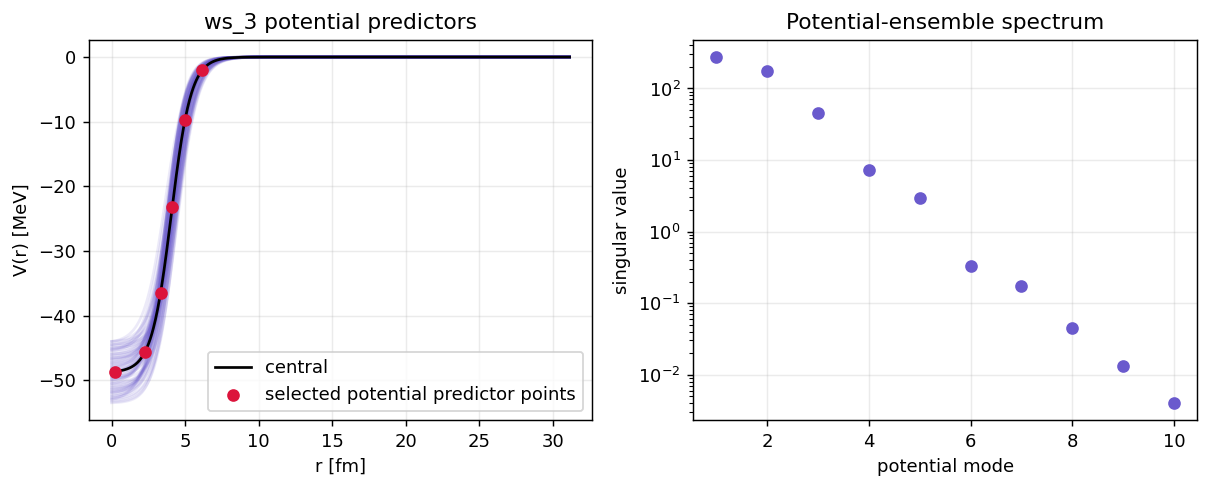

In [8]:
r3 = ws3_emulator.mesh.radius
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for potential in ws3_emulator.samples.training_potentials:
    axes[0].plot(r3, np.real(potential), color="slateblue", alpha=0.12)
axes[0].plot(r3, np.real(ws3_emulator.samples.central_potential), color="black", label="central")
selected_radii = ws3_emulator.predictors.selected_radii
selected_values = ws3_emulator.samples.central_potential[
    ws3_emulator.predictors.selected_indices
]
axes[0].scatter(
    selected_radii,
    np.real(selected_values),
    color="crimson",
    zorder=5,
    label="selected potential predictor points",
)
axes[0].set(xlabel="r [fm]", ylabel="V(r) [MeV]", title="ws_3 potential predictors")
axes[0].legend()

for index, singular_value in enumerate(ws3_emulator.predictors.singular_values[:10], start=1):
    axes[1].semilogy(index, singular_value, "o", color="slateblue")
axes[1].set(xlabel="potential mode", ylabel="singular value", title="Potential-ensemble spectrum")
plt.show()

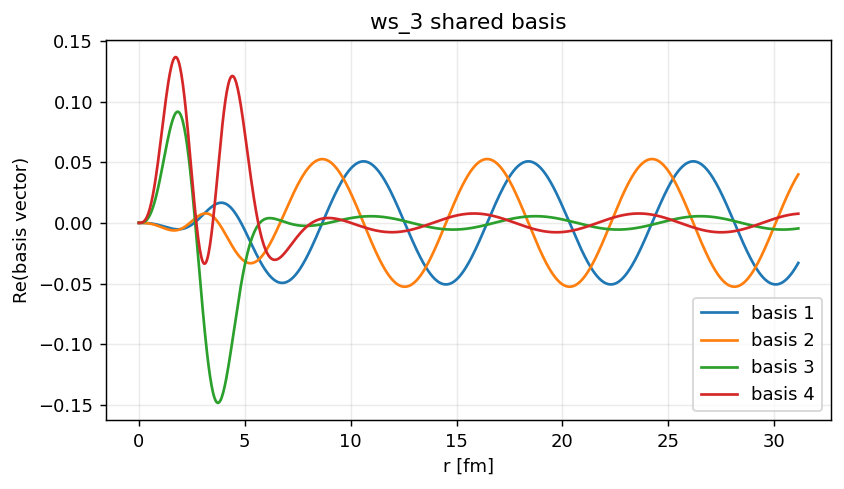

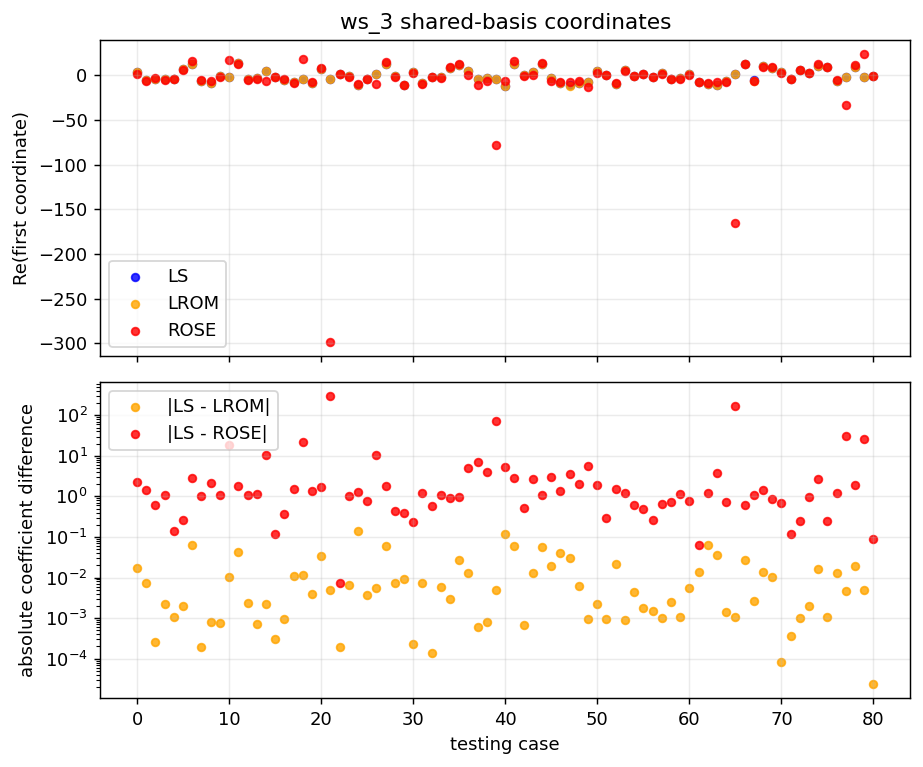

In [9]:
ws3_basis = ws3_emulator.basis[0]
fig, ax = plt.subplots(figsize=(7.2, 3.8))
for index in range(ws3_basis.basis_size):
    ax.plot(r3, np.real(ws3_basis.vectors[:, index]), label=f"basis {index + 1}")
ax.set(xlabel="r [fm]", ylabel="Re(basis vector)", title="ws_3 shared basis")
ax.legend()
plt.show()

coefficients = {key: dict(value) for key, value in ws3_emulator.testing_results.coefficients.items()}
coefficients["rose"] = {0: ws3_rose_coefficients}
case_number = np.arange(ws3_emulator.samples.design.testing.values.shape[0])
fig, axes = plt.subplots(2, 1, figsize=(7.2, 6.0), sharex=True)
for method, color in (("ls", "blue"), ("lrom", "orange"), ("rose", "red")):
    axes[0].scatter(
        case_number,
        np.real(coefficients[method][0][:, 0]),
        s=18,
        color=color,
        alpha=0.8,
        label=method.upper(),
    )
ws3_ls_coefficients = np.real(coefficients["ls"][0][:, 0])
for method, color in (("lrom", "orange"), ("rose", "red")):
    method_coefficients = np.real(coefficients[method][0][:, 0])
    axes[1].scatter(
        case_number,
        np.maximum(np.abs(ws3_ls_coefficients - method_coefficients), 1e-16),
        s=18,
        color=color,
        alpha=0.8,
        label=f"|LS - {method.upper()}|",
    )
axes[0].set(ylabel="Re(first coordinate)", title="ws_3 shared-basis coordinates")
axes[1].set_yscale("log")
axes[1].set(xlabel="testing case", ylabel="absolute coefficient difference")
axes[0].legend()
axes[1].legend()
fig.tight_layout()
plt.show()

## Section 3. Three-Parameter Wavefunction Emulation Results

We now inspect one representative testing solution and compare the
training and testing relative-error distributions. The least-squares
curve is the attainable floor for this fixed basis.

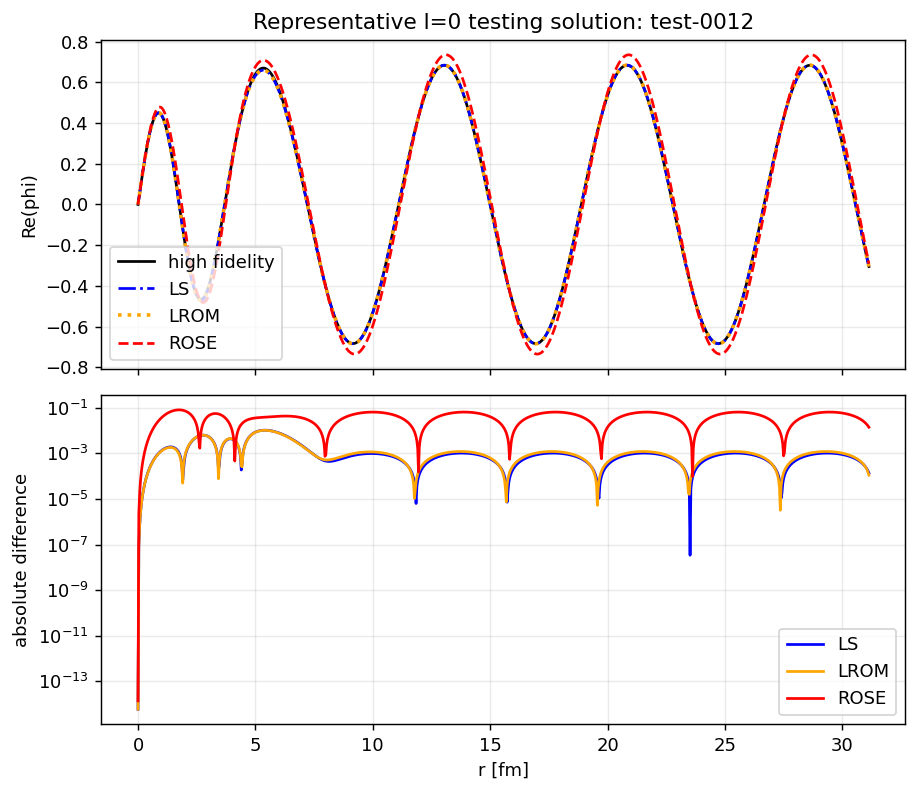

In [10]:
lrom_relative = ws3_emulator.testing_results.metrics["relative_l2"][0]["lrom"]
representative_index = int(np.argsort(lrom_relative)[len(lrom_relative) // 2])
representative_id = ws3_emulator.samples.design.testing.case_ids[representative_index]
case = ws3_emulator.testing_case(case_id=representative_id)

fig, axes = plt.subplots(2, 1, figsize=(7.2, 6.2), sharex=True)
axes[0].plot(case.radius, np.real(case.high_fidelity[0]), color="black", label="high fidelity")
axes[0].plot(case.radius, np.real(case.ls[0]), "-.", color="blue", label="LS")
axes[0].plot(case.radius, np.real(case.lrom[0]), ":", color="orange", linewidth=2, label="LROM")
axes[0].plot(case.radius, np.real(ws3_rose_wf_test[representative_index]), "--", color="red", label="ROSE")
axes[0].set_ylabel("Re(phi)")
axes[0].set_title(f"Representative l=0 testing solution: {representative_id}")
axes[0].legend()
axes[1].plot(case.radius, np.maximum(np.abs(case.high_fidelity[0] - case.ls[0]), 1e-16), color="blue", label="LS")
axes[1].plot(case.radius, np.maximum(np.abs(case.high_fidelity[0] - case.lrom[0]), 1e-16), color="orange", label="LROM")
axes[1].plot(case.radius, np.maximum(np.abs(case.high_fidelity[0] - ws3_rose_wf_test[representative_index]), 1e-16), color="red", label="ROSE")
axes[1].set_yscale("log")
axes[1].set_xlabel("r [fm]")
axes[1].set_ylabel("absolute difference")
axes[1].legend()
fig.tight_layout()
plt.show()

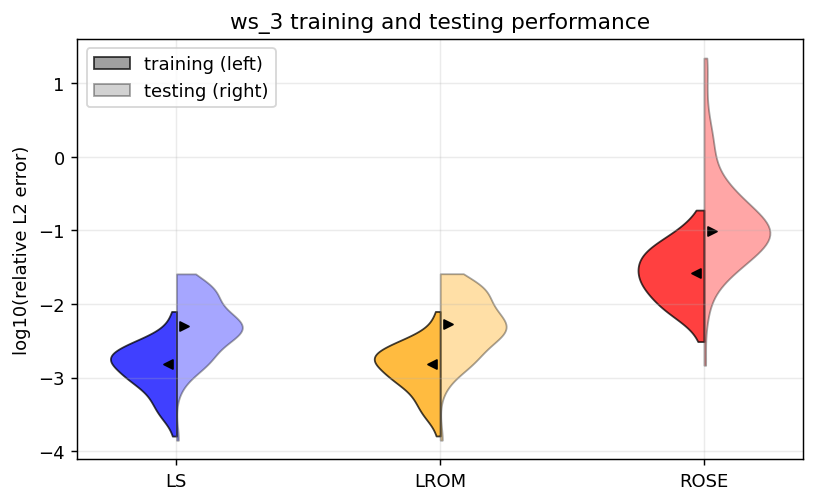

In [11]:
methods = ("ls", "lrom", "rose")
colors = ("blue", "orange", "red")
positions = np.arange(1, 4)
training_metrics = dict(ws3_emulator.training_results.metrics["relative_l2"][0])
training_metrics["rose"] = ws3_rose_rel_train
testing_metrics = dict(ws3_emulator.testing_results.metrics["relative_l2"][0])
testing_metrics["rose"] = ws3_rose_rel_test
training_values = [
    np.log10(np.maximum(training_metrics[method], 1e-16))
    for method in methods
]
testing_values = [
    np.log10(np.maximum(testing_metrics[method], 1e-16))
    for method in methods
]
fig, ax = plt.subplots(figsize=(7.2, 4.2))
training_violin = ax.violinplot(
    training_values,
    positions=positions,
    showextrema=False,
)
testing_violin = ax.violinplot(
    testing_values,
    positions=positions,
    showextrema=False,
)
for center, body, color in zip(positions, training_violin["bodies"], colors):
    vertices = body.get_paths()[0].vertices
    vertices[:, 0] = np.minimum(vertices[:, 0], center)
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.75)
for center, body, color in zip(positions, testing_violin["bodies"], colors):
    vertices = body.get_paths()[0].vertices
    vertices[:, 0] = np.maximum(vertices[:, 0], center)
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.35)
ax.scatter(positions - 0.03, [np.median(values) for values in training_values], color="black", marker="<", s=24)
ax.scatter(positions + 0.03, [np.median(values) for values in testing_values], color="black", marker=">", s=24)
ax.set_xticks(positions, [method.upper() for method in methods])
ax.set_ylabel("log10(relative L2 error)")
ax.set_title("ws_3 training and testing performance")
ax.legend(handles=[
    Patch(facecolor="gray", edgecolor="black", alpha=0.75, label="training (left)"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.35, label="testing (right)"),
])
plt.show()

In [12]:
test_values = ws3_emulator.samples.design.testing.values
names = ws3_emulator.parameter_names
interpolation = np.ones(len(test_values), dtype=bool)
for column, name in enumerate(names):
    low, high = ws3_training_ranges[name]
    interpolation &= (test_values[:, column] >= low) & (test_values[:, column] <= high)

rows = []
metrics = dict(ws3_emulator.testing_results.metrics["relative_l2"][0])
metrics["rose"] = ws3_rose_rel_test
for region, mask in (("interpolation", interpolation), ("extrapolation", ~interpolation)):
    for method in ("rose", "lrom", "ls"):
        values = metrics[method][mask]
        rows.append(
            {
                "region": region,
                "method": method.upper(),
                "cases": int(mask.sum()),
                "median relative L2": float(np.median(values)),
                "maximum relative L2": float(np.max(values)),
            }
        )
pd.DataFrame(rows).set_index(["region", "method"])

cases  median relative L2  maximum relative L2
region        method                                                
interpolation ROSE        9            0.027762             0.080888
              LROM        9            0.001462             0.003065
              LS          9            0.001449             0.003065
extrapolation ROSE       72            0.104944            22.068844
              LROM       72            0.005726             0.025804
              LS         72            0.005419             0.025693

In [13]:
artifact_path = ROOT / "outputs" / "notebook01_ws3_model.lrom"
ws3_emulator.save(path=artifact_path)
portable_emulator = lrom.load(path=artifact_path)
portable_emulator.predict(parameters=case.parameters)
print("portable model:", artifact_path)
print("prediction shape:", portable_emulator.predictions.wavefunctions[0].shape)

portable model: /Users/Kitkat/Documents/Documents-Agent/LROM_Project/outputs/notebook01_ws3_model.lrom
prediction shape: (1, 900)
